In [22]:
import pandas as pd
import numpy as np

# Load the datasets using relative paths
train_df = pd.read_csv('../data/train.csv')
features_df = pd.read_csv('../data/features.csv')
stores_df = pd.read_csv('../data/stores.csv')

# Verify the data loaded correctly
print("--- Data Successfully Loaded ---")
print(f"Train records: {train_df.shape[0]}")
print(f"Feature records: {features_df.shape[0]}")
print(f"Stores records: {stores_df.shape[0]}")

--- Data Successfully Loaded ---
Train records: 421570
Feature records: 8190
Stores records: 45


In [23]:
# Check Data Types & Missing Values for the Features dataset
# Missing MarkDown data will show up
print("--- Features Dataset Info & Missing Values ---")
features_df.info()
print("\nMissing Values Count:")
print(features_df.isnull().sum())

# Statistical Summary of the Target Variable (Weekly Sales)
print("\n--- Target Varible (Weekly Sales) Summary ---")
# Setting Formatting
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(train_df['Weekly_Sales'].describe())

--- Features Dataset Info & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB

Missing Values Count:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       

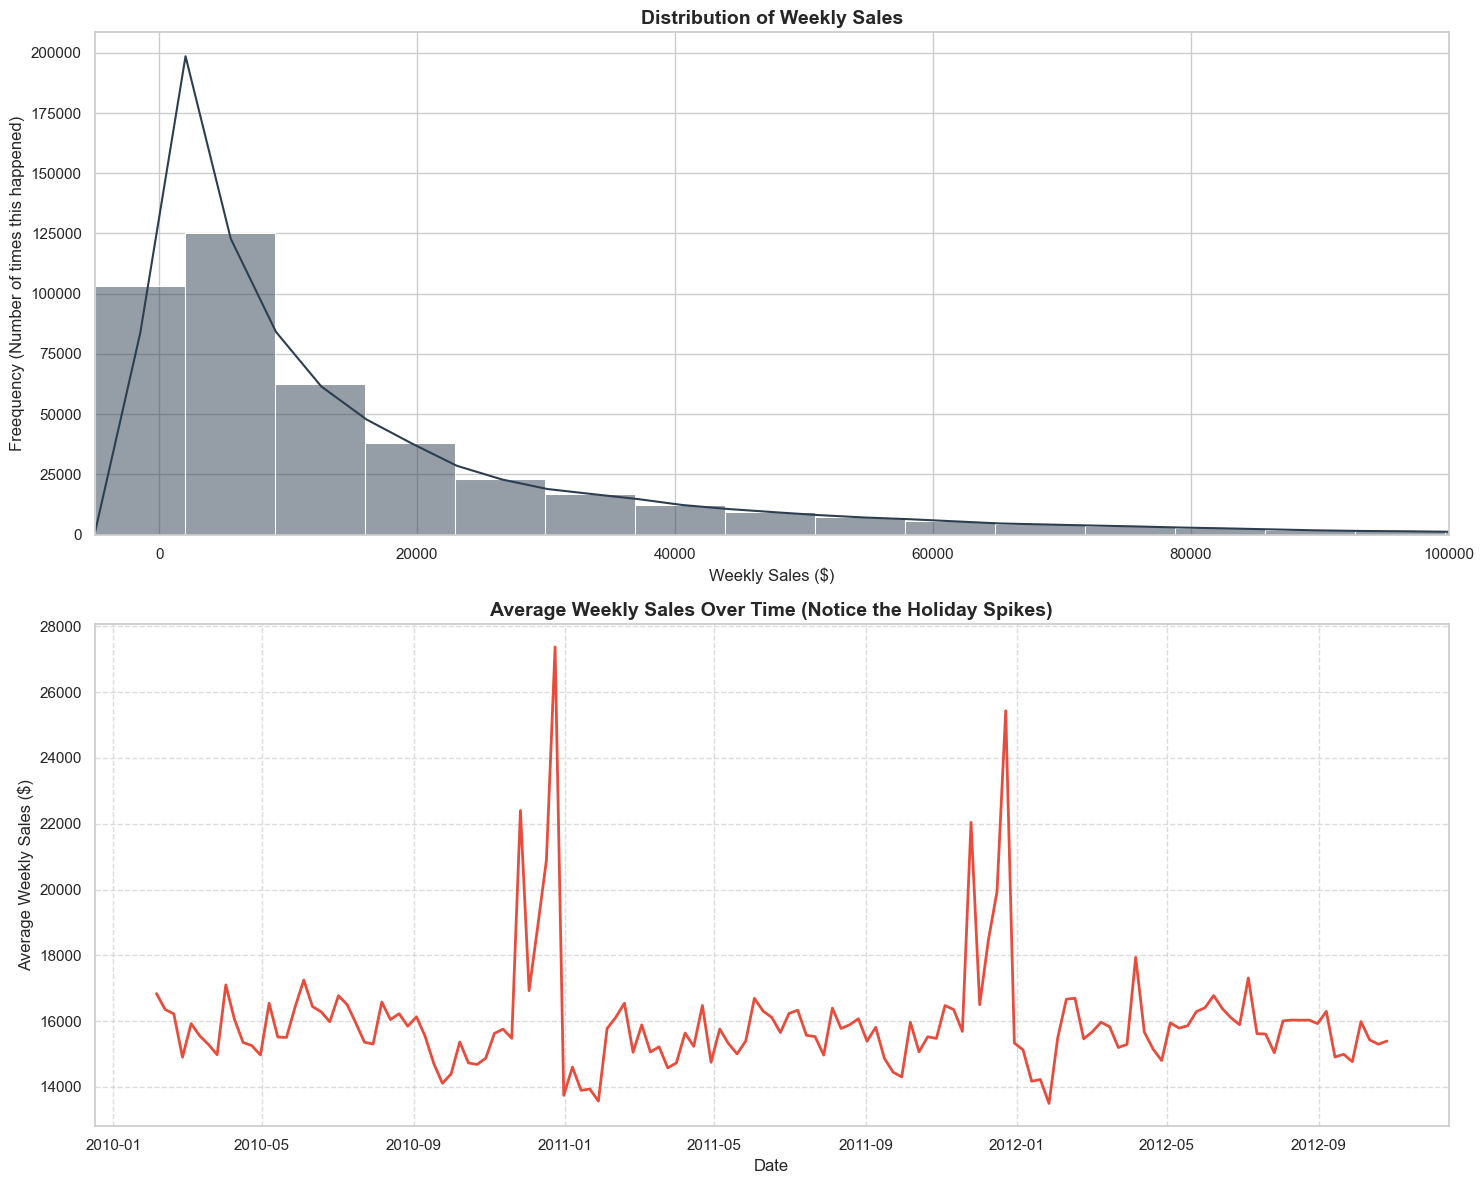

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Date from text to a mathematical Datetime objects
train_df['Date'] = pd.to_datetime(train_df['Date'])

# Set up the "canvas" for charts 
plt.figure(figsize=(15, 12))

# Chart 1: The Distribution of Sales (Histogram)
plt.subplot(2, 1, 1) # 2 rows, 1 column, 1st chart
sns.histplot(train_df['Weekly_Sales'], bins=100, color='#2c3e50', kde=True)
plt.title('Distribution of Weekly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Sales ($)', fontsize=12)
plt.ylabel('Freequency (Number of times this happened)', fontsize=12)
# limit the X-axis because a few massive sales make the chart unreadable otherwise
plt.xlim(-5000, 100000)

# Chart 2: Sales Overtime (Line Chart)
plt.subplot(2, 1, 2) # 2 rows, 1 column, 2nd chart
# average the sales across all stores for each week to see the pig picture
weekly_avg_sales = train_df.groupby('Date')['Weekly_Sales'].mean().reset_index()

sns.lineplot(data=weekly_avg_sales, x='Date', y='Weekly_Sales', color='#e74c3c', linewidth=2)
plt.title('Average Weekly Sales Over Time (Notice the Holiday Spikes)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [25]:
# Data Pre Processing
print("--- Starting Data Merge ---")

# Convert features_df 'Date' to datetime so it matches train_df
features_df['Date'] = pd.to_datetime(features_df['Date'])

# Merge train data with store data
# Match them using the 'Store' ID column
merged_df = train_df.merge(stores_df, on='Store', how='left')

# Clean up duplicate columns before the final merge
# Both train_df and features_df have 'IsHoliday' coloumn
# Drop it from features to avoid getting messy 'IsHoliday_x' and 'IsHoliday_y columns.
features_clean = features_df.drop(columns=['IsHoliday'])

# Merge the result with features data
# Must match on Both 'Store' and 'Date' to get the exact weather/economy for that specific week.
final_df = merged_df.merge(features_clean, on=['Store', 'Date'], how='left')

print(f"Final Merged Dataset Shape: {final_df.shape}")

# Show the first 5 rows to visually confirsm the merge worked
pd.set_option('display.max_columns', None) # Force pandas to show all columns
final_df.head()

--- Starting Data Merge ---
Final Merged Dataset Shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11


In [26]:
print("--- Handling Missing Values & Feature Engineering ---")

# Handle Missing MarkDown Data
# 'NaN' in markdown simple means walmart wasn't running a promotion that weekk. Replace NaN with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
final_df[markdown_cols] = final_df[markdown_cols].fillna(0)

# Handle missing Economics Data (CPI & Unemployment)
# Fill the few missing economics values with the overall average (mean)
final_df['CPI'] = final_df['CPI'].fillna(final_df['CPI'].mean())
final_df['Unemployement'] = final_df['Unemployment'].fillna(final_df['Unemployment'].mean())

# Time-Series Feature Extraction
# ML module don't understand dates. Extracts the week number and year as math number
final_df['Week'] = final_df['Date'].dt.isocalendar().week
final_df['Year'] = final_df['Date'].dt.year

# Convert CAtegorical Data to Numbers
# Convert True/False holidays to 0 & 1
final_df['IsHoliday'] = final_df['IsHoliday'].astype(int)

# Convert Store 'Type' (A, B, C) into numbers using One-Hot Encoding
# Creates new columns like 'Type_B' and 'Type_C' with 1s and 0s
final_df = pd.get_dummies(final_df, columns=['Type'], drop_first=True)

print(f"Missing values remaining: {final_df.isnull().sum().sum()}")

# Show the cleaned data
pd.set_option('display.max_columns', None)
final_df.head()

--- Handling Missing Values & Feature Engineering ---
Missing values remaining: 0


,Store,Dept,Date,Weekly_Sales,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Unemployement,Week,Year,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,151315,42.31,2.57,0.00,0.00,0.00,0.00,0.00,211.10,8.11,8.11,5,2010,False,False
1,1,1,2010-02-12,46039.49,1,151315,38.51,2.55,0.00,0.00,0.00,0.00,0.00,211.24,8.11,8.11,6,2010,False,False
2,1,1,2010-02-19,41595.55,0,151315,39.93,2.51,0.00,0.00,0.00,0.00,0.00,211.29,8.11,8.11,7,2010,False,False
3,1,1,2010-02-26,19403.54,0,151315,46.63,2.56,0.00,0.00,0.00,0.00,0.00,211.32,8.11,8.11,8,2010,False,False
4,1,1,2010-03-05,21827.90,0,151315,46.50,2.62,0.00,0.00,0.00,0.00,0.00,211.35,8.11,8.11,9,2010,False,False


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("--- Model Training (Random Forest) ---")

# Force the entire dataset to sort chronologically first!
final_df = final_df.sort_values(by=['Year', 'Week'])

# Prepare the Features (X) and Target (Y)
# Drop 'Weekly_Sales' (the answer key) and 'Date' (models can't read datetime objects)
X = final_df.drop(columns=['Weekly_Sales', 'Date'])
y = final_df['Weekly_Sales']

# Split the data (80% for training, 20% for testing)
# Set shuffle=False to respect the time-series nature (train on the past, test on the future)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows")
print("Training the Random Forest...")

# Initialize and Train the Model
# n_jobs=-1 uses all CPU cores. n_estimators=50 builds 50 decision trees.
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make Predictions and Evaluate
predictions = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("\n--- Model Results ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

--- Model Training (Random Forest) ---
Training Data: 337256 rows
Testing Data: 84314 rows
Training the Random Forest...

--- Model Results ---
Mean Absolute Error (MAE): $1,873.84
Root Mean Squared Error (RMSE): $3,984.80


--- Generating Feature Importance ---


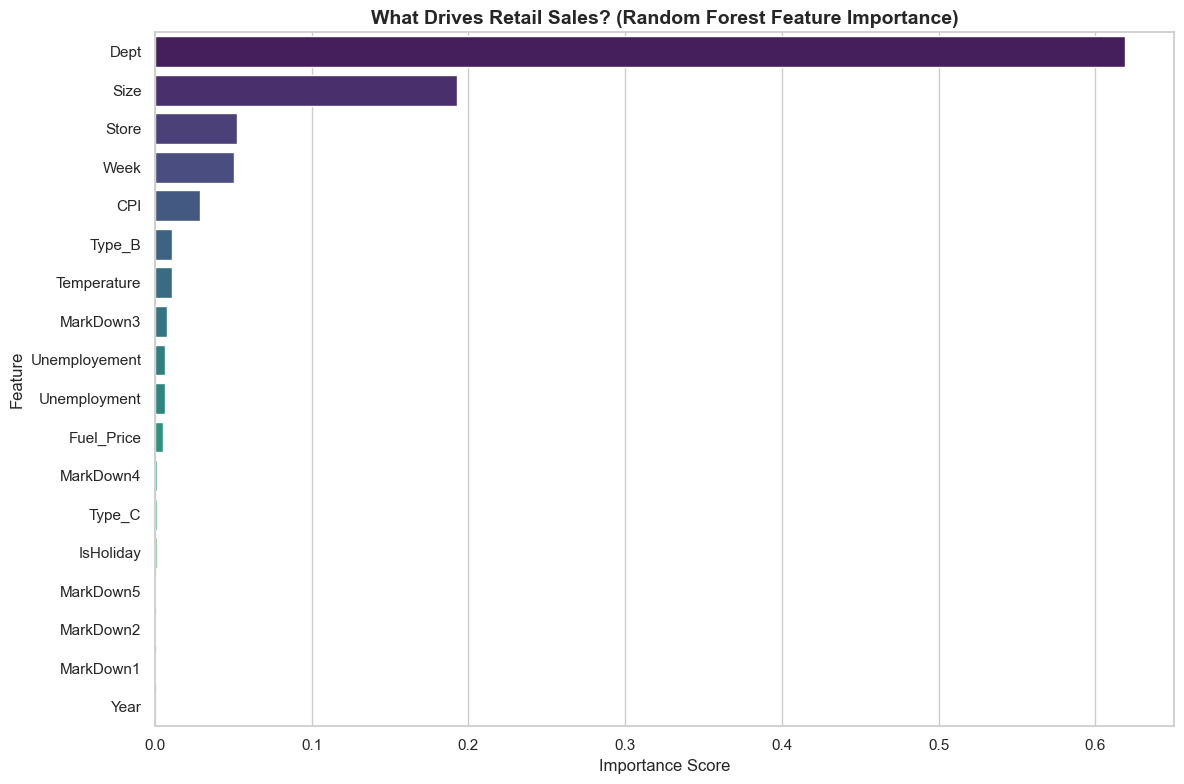

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- Generating Feature Importance ---")

# Extract the importance scores directly from the trained model
importances = rf_model.feature_importances_

# Map the scores to the column names and sort them
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Draw the horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('What Drives Retail Sales? (Random Forest Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("---XGBoost Model Training---")
print("Routing training to the GPU...")

# Initialize the XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100, # Build 100 trees sequentially to fix mistakes
    learning_rate=0.1, # How aggresive it should be when learning
    random_state=42,
    tree_method='hist',
    device='cuda'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions & Evaluate
xgb_predictions = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("\n---XGBoost Results---")
print(f"Mean Absolute Error (MAE): ${xgb_mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${xgb_rmse:,.2f}")

---XGBoost Model Training---
Routing training to the GPU...

---XGBoost Results---
Mean Absolute Error (MAE): $3,994.10
Root Mean Squared Error (RMSE): $6,502.27


In [30]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("---Hyperparameter Tuning---")
print("Searching for the best XGBoost engine settings...")

# Define the grid of settings to test
param_grid = {
    'max_depth': [3, 5, 7, 9],               # How deep the trees can grow
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # How fast it learns from mistakes
    'n_estimators': [100, 200, 300],         # Total number of trees
    'subsample': [0.8, 0.9, 1.0]             # Percentage of data used per tree
}

# Initialize the base model
xgb_base = xgb.XGBRegressor(random_state=42, tree_method='hist', device='cuda')

# Create a Time-Series-Aware cross validator
# This ensures it never uses future data to validate past patterns
tscv = TimeSeriesSplit(n_splits=3)

# Set up the Randomized Search
# This will test 10 random combinations from the grid above to save time
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10, 
    scoring='neg_mean_absolute_error',
    cv=tscv, # perfectly respects the timeline
    verbose=2,
    random_state=42,
    n_jobs=1 # Keep at 1 so the GPU doesn't crash from memory overload
)

# Run the search
random_search.fit(X_train, y_train)

print(f"\nBest Settings Found: {random_search.best_params_}")

# Evaluate the newly tuned model
best_xgb = random_search.best_estimator_
tuned_predictions = best_xgb.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))

print("\n--- TUNED XGBOOST RESULTS ---")
print(f"New Mean Absolute Error (MAE): ${tuned_mae:,.2f}")
print(f"New Root Mean Squared Error (RMSE): ${tuned_rmse:,.2f}")

---Hyperparameter Tuning---
Searching for the best XGBoost engine settings...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END learning_rate=0.2, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.9; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.9; total time=   0.3s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.9; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.9; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.9; total time=   0.2s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.9; total time=   0.2s
[CV] END learning_rat

In [32]:
import joblib

print("---Exporting the Winning Model---")

# Save the Random Forest model to a file
joblib.dump(rf_model, 'apex_rf_model.joblib')

# Save the exact column names the model was trained on
joblib.dump(list(X_train.columns), 'model_columns.joblib')

print("Success! Random Forest Model & columns saved to the project folder.")

---Exporting the Winning Model---
Success! Random Forest Model & columns saved to the project folder.


---Model Evaluation Visualizations---


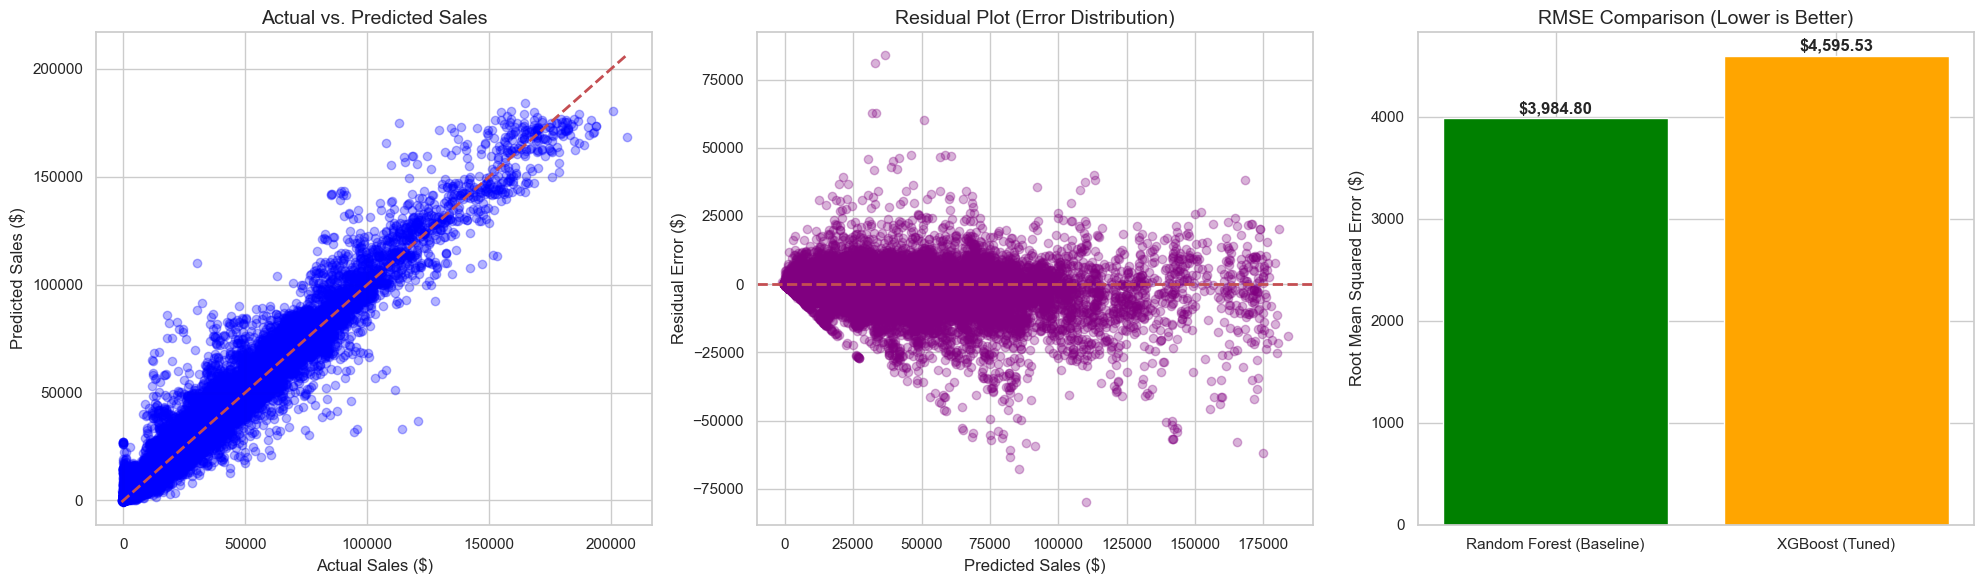

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

print("---Model Evaluation Visualizations---")

# Set global plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Actual vs Predicted (Random Forest)
axes[0].scatter(y_test, predictions, alpha=0.3, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Sales', fontsize=14)
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')

# Plot 2: Residual Plot (Error Distribution)
residuals = y_test - predictions
axes[1].scatter(predictions, residuals, alpha=0.3, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title('Residual Plot (Error Distribution)', fontsize=14)
axes[1].set_xlabel('Predicted Sales ($)')
axes[1].set_ylabel('Residual Error ($)')

# Plot 3: Metric Comparison Chart
models = ['Random Forest (Baseline)', 'XGBoost (Tuned)']
rmse_scores = [3984.80, 4595.53] 

axes[2].bar(models, rmse_scores, color=['green', 'orange'])
axes[2].set_title('RMSE Comparison (Lower is Better)', fontsize=14)
axes[2].set_ylabel('Root Mean Squared Error ($)')

for i, v in enumerate(rmse_scores):
    axes[2].text(i, v + 50, f"${v:,.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()